# Q5: Deep Learning vs Classical ML for DDoS Detection

**Research Question:** Do deep learning (DL) models outperform classical ML models for DDoS detection, and does this advantage hold under the more demanding time-split and cross-network evaluation conditions?

**Why it matters:** Deep learning models are often advocated for network intrusion detection due to their capacity to learn complex, non-linear patterns. However, classical ML methods are faster to train, easier to interpret, and may generalise better when distribution shifts occur between training and deployment environments. Understanding which category is more appropriate — and under which conditions — has direct practical implications for DDoS detection system design.

**Model categories:**
| Category | Models |
|----------|--------|
| Deep Learning | GRU, LSTM, RNN, MLP, NN |
| Classical ML | KNN, LightGBM, Logistic Regression, Random Forest, SVM, XGBoost |

**Approach:** Both categories are evaluated in-network (train set = test set) and cross-network (train on one network, test on another) across all four SCLDDoS2024 networks (SetA–SetD), both task types (Binary/Multiclass), both split strategies (Random/Time), and both feature approaches (Sequence/Component). Mean F1 and statistical significance tests are used throughout.

**Component-based evaluation: per-component and per-event metrics**

Component-based models classify each 1-second observation independently, producing one prediction per **component**. Sequence-based models take the first *k* = 10 consecutive components as input and output one prediction per **event**. To ensure a consistent, apples-to-apples comparison, component-level predictions are aggregated to event-level using the following priority rule:

- **Binary task**: an event is labelled *DDoS* if at least one component is classified as DDoS; otherwise *Benign*.
- **Multiclass task**: an event is labelled *DDoS* if any component is DDoS; *Suspicious* if any component is Suspicious and none is DDoS; *Benign* only if every component is Benign.

Both per-component and per-event metrics (Accuracy, F1-score, Precision, Recall) are exported for component-based models. The **per-event** results are used throughout all DL vs Classical ML comparisons. See `evaluation_event_metrics.py` for the full implementation.

**Key findings:**
- **In-network**: DL leads (+0.027 F1, significant in 75% of conditions); LSTM is the best individual model (0.844).
- **Cross-network**: Classical ML leads (+0.015 F1); Random Forest is the best individual model (0.573).
- DL's in-network advantage is largest under time-split (+0.04 F1), suggesting stronger temporal generalisation.
- Tree ensembles (RF, LightGBM, XGBoost) dominate the cross-network top-3 — robustness offsets raw performance.

The following setup cell imports the required Python libraries, defines the DL and Classical model groupings, and configures the visual style and directory structure used throughout this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import wilcoxon
from itertools import product
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = Path('../data/wandb_export_final_hyperparameters.csv')
FIG_DIR   = Path('figures');  FIG_DIR.mkdir(exist_ok=True)
TAB_DIR   = Path('tables');   TAB_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
NETWORKS    = ['SetA', 'SetB', 'SetC', 'SetD']
PRIMARY     = 'f1_score'

# Model categorisation
DL_MODELS      = ['gru', 'lstm', 'rnn', 'mlp', 'nn']
CLASSICAL_MODELS = ['knn', 'lightgbm', 'logistic-regression',
                    'random-forest', 'svm', 'xgboost']
ALL_MODELS     = DL_MODELS + CLASSICAL_MODELS

CAT_PALETTE = {'Deep Learning': '#7B1FA2', 'Classical ML': '#E65100'}

All required libraries are imported. Deep Learning models (GRU, LSTM, RNN, MLP, NN) and Classical ML models (KNN, LightGBM, Logistic Regression, Random Forest, SVM, XGBoost) are defined. The visual theme and output directories are configured.

The next cell loads the experiment results CSV and reshapes it from wide to long format. It assigns each model to either the 'Deep Learning' or 'Classical ML' category and extracts both in-network and cross-network evaluation entries.

In [2]:
raw = pd.read_csv(DATA_PATH, index_col=0)
raw = raw[raw['split'] != "Random with same distribution"]

metric_cols = [c for c in raw.columns if c.count('/') == 2]
id_vars = ['model', 'task', 'split', 'enable_sequences', 'run_no']

long = raw[id_vars + metric_cols].melt(
    id_vars=id_vars, value_vars=metric_cols,
    var_name='metric_key', value_name='value'
)
long[['train_set', 'test_set', 'metric']] = long['metric_key'].str.split('/', expand=True)
long = long.drop(columns='metric_key')

long['category']  = long['model'].map(
    lambda m: 'Deep Learning' if m in DL_MODELS else 'Classical ML')
long['eval_type'] = np.where(
    long['train_set'] == long['test_set'], 'In-network', 'Cross-network')

f1 = long[long['metric'] == PRIMARY].copy()

inset = f1[f1['eval_type'] == 'In-network'].copy()
cross = f1[f1['eval_type'] == 'Cross-network'].copy()

print(f'F1 rows total:        {len(f1):,}')
print(f'In-network rows:      {len(inset):,}')
print(f'Cross-network rows:   {len(cross):,}')
print(f'\nModel categories:')
print(f'  Deep Learning: {DL_MODELS}')
print(f'  Classical ML:  {CLASSICAL_MODELS}')

F1 rows total:        9,712
In-network rows:      2,428
Cross-network rows:   7,284

Model categories:
  Deep Learning: ['gru', 'lstm', 'rnn', 'mlp', 'nn']
  Classical ML:  ['knn', 'lightgbm', 'logistic-regression', 'random-forest', 'svm', 'xgboost']


The dataset is loaded and reshaped into a long-format DataFrame. Each row is a model's F1 score for a specific (run, task, split, approach, train_set, test_set) setting, with a `category` column distinguishing Deep Learning from Classical ML models.

The next cell averages F1 scores across training runs for each unique experimental configuration, reducing run-level noise. It retains the model category (DL or Classical) label for group-level analysis.

In [3]:
group_keys = ['model', 'category', 'task', 'split', 'enable_sequences',
              'train_set', 'test_set', 'eval_type']

avg = (f1.groupby(group_keys, as_index=False)['value']
          .agg(['mean', 'std', 'count'])
          .rename(columns={'mean': 'mean_f1', 'std': 'std_f1', 'count': 'n_runs'}))

avg_in    = avg[avg['eval_type'] == 'In-network'].copy()
avg_cross = avg[avg['eval_type'] == 'Cross-network'].copy()

print('Averaged rows (all):', len(avg))
print('Averaged rows (in-network):', len(avg_in))
print(avg_in.head(3))

Averaged rows (all): 1152
Averaged rows (in-network): 288
   model       category    task         split  enable_sequences train_set  \
0    gru  Deep Learning  Binary  Random split             False      SetA   
5    gru  Deep Learning  Binary  Random split             False      SetB   
10   gru  Deep Learning  Binary  Random split             False      SetC   

   test_set   eval_type   mean_f1  std_f1  n_runs  
0      SetA  In-network  0.817911     NaN       1  
5      SetB  In-network  0.700062     NaN       1  
10     SetC  In-network  0.700855     NaN       1  


The aggregated DataFrame now has one row per (model, category, task, split, approach, train_set, test_set, eval_type) configuration with its mean F1. Each row is tagged as DL or Classical, enabling direct category-level comparisons throughout.

The next cell produces Table 1, the top-level DL vs Classical summary across all conditions. It provides a single reference point for the overall performance difference between the two model families.

In [4]:
# ── Table 1: Overall DL vs Classical — in-network and cross-network ───────────
records = []
for eval_type, sub in [('In-network', avg_in), ('Cross-network', avg_cross)]:
    for task in ['Binary', 'Multiclass']:
        for split in ['Random split', 'Time split']:
            row = {'Eval type': eval_type, 'Task': task, 'Split': split}
            for cat in ['Deep Learning', 'Classical ML']:
                v = sub[(sub['category']==cat)&(sub['task']==task)&
                        (sub['split']==split)]['mean_f1'].mean()
                row[cat] = round(v, 4)
            row['DL − Classical'] = round(row['Deep Learning'] - row['Classical ML'], 4)
            records.append(row)

t1 = pd.DataFrame(records)
print('Table 1: Overall DL vs Classical ML — Mean F1')
print(t1.to_string(index=False))
t1.to_csv(TAB_DIR / 'table1_overall_dl_vs_classical.csv', index=False)

latex1 = t1.to_latex(index=False, float_format='%.4f',
    caption=r'Overall mean F1-score comparison: deep learning vs.\ classical ML '
            r'under in-network and cross-network evaluation, averaged over all '
            r'networks, models within each category, and approaches. '
            r'DL $-$ Classical: positive = deep learning advantage.',
    label='tab:q5_overall')
(TAB_DIR / 'table1_overall_dl_vs_classical.tex').write_text(latex1)
print('Saved Table 1.')

Table 1: Overall DL vs Classical ML — Mean F1
    Eval type       Task        Split  Deep Learning  Classical ML  DL − Classical
   In-network     Binary Random split         0.8711        0.8503          0.0208
   In-network     Binary   Time split         0.8114        0.7627          0.0487
   In-network Multiclass Random split         0.7911        0.7730          0.0181
   In-network Multiclass   Time split         0.7057        0.6552          0.0505
Cross-network     Binary Random split         0.5751        0.6038         -0.0287
Cross-network     Binary   Time split         0.5912        0.6010         -0.0098
Cross-network Multiclass Random split         0.4308        0.4387         -0.0079
Cross-network Multiclass   Time split         0.4572        0.4421          0.0151
Saved Table 1.


Table 1 gives the headline comparison: DL vs Classical mean F1 under all conditions combined (in-network and cross-network, all tasks, both splits). This establishes the overall picture before the per-network and per-condition breakdowns.

The next cell builds Table 2, a per-network per-task comparison of DL and Classical mean in-network F1. It provides the granular view needed to judge whether DL's overall advantage holds across all four network environments.

In [5]:
# ── Table 2: Per-network DL vs Classical (in-network, both tasks) ─────────────
records = []
for net in NETWORKS:
    for task in ['Binary', 'Multiclass']:
        row = {'Network': net, 'Task': task}
        for cat in ['Deep Learning', 'Classical ML']:
            v = avg_in[(avg_in['test_set']==net)&(avg_in['category']==cat)&
                       (avg_in['task']==task)]['mean_f1'].mean()
            row[cat] = round(v, 4)
        row['DL − Classical'] = round(row['Deep Learning'] - row['Classical ML'], 4)
        row['Advantage'] = (
            'DL' if row['DL − Classical'] > 0.01
            else ('Classical' if row['DL − Classical'] < -0.01 else '≈ Tie'))
        records.append(row)

t2 = pd.DataFrame(records)
print('Table 2: Per-Network DL vs Classical ML (In-network evaluation)')
print(t2.to_string(index=False))
t2.to_csv(TAB_DIR / 'table2_per_network_dl_vs_classical.csv', index=False)

latex2 = t2.to_latex(index=False, float_format='%.4f',
    caption=r'Per-network mean F1-score: deep learning vs.\ classical ML '
            r'(in-network evaluation, averaged over models within each category, '
            r'splits, and approaches). Advantage: DL if gap $>0.01$, Classical if gap $<-0.01$.',
    label='tab:q5_per_network')
(TAB_DIR / 'table2_per_network_dl_vs_classical.tex').write_text(latex2)
print('Saved Table 2.')

Table 2: Per-Network DL vs Classical ML (In-network evaluation)
Network       Task  Deep Learning  Classical ML  DL − Classical Advantage
   SetA     Binary         0.6393        0.6873         -0.0480 Classical
   SetA Multiclass         0.5309        0.5821         -0.0512 Classical
   SetB     Binary         0.8876        0.7787          0.1089        DL
   SetB Multiclass         0.8315        0.7472          0.0843        DL
   SetC     Binary         0.8678        0.7968          0.0710        DL
   SetC Multiclass         0.7296        0.6457          0.0839        DL
   SetD     Binary         0.9703        0.9633          0.0070     ≈ Tie
   SetD Multiclass         0.9015        0.8814          0.0201        DL
Saved Table 2.


Table 2 breaks down the DL vs Classical comparison per network for in-network evaluation, separately for Binary and Multiclass tasks. It shows whether the DL advantage is consistent across networks and task types, or concentrated in specific settings.

The next cell constructs Table 3, ranking all individual models by their mean F1 in both evaluation regimes. It identifies the best and worst performers in each category and whether the in-network top performers carry over to cross-network.

In [6]:
# ── Table 3: Per-model ranking — in-network and cross-network ─────────────────
records = []
for model in ALL_MODELS:
    cat = 'Deep Learning' if model in DL_MODELS else 'Classical ML'
    in_all   = avg_in[avg_in['model']==model]['mean_f1'].mean()
    in_rand  = avg_in[(avg_in['model']==model)&
                      (avg_in['split']=='Random split')]['mean_f1'].mean()
    in_time  = avg_in[(avg_in['model']==model)&
                      (avg_in['split']=='Time split')]['mean_f1'].mean()
    cross_all = avg_cross[avg_cross['model']==model]['mean_f1'].mean()
    records.append({
        'Model':              model,
        'Category':           cat,
        'In-net (overall)':   round(in_all,   4),
        'In-net (rand)':      round(in_rand,  4),
        'In-net (time)':      round(in_time,  4),
        'Cross-net (overall)':round(cross_all,4),
        'Time split drop':    round(in_rand - in_time, 4),
        'Transfer drop':      round(in_all   - cross_all, 4),
    })

t3 = (pd.DataFrame(records)
        .sort_values('In-net (overall)', ascending=False)
        .reset_index(drop=True))

print('Table 3: Per-Model F1 Ranking (sorted by in-network F1)')
print(t3.to_string(index=False))
t3.to_csv(TAB_DIR / 'table3_per_model_ranking.csv', index=False)

latex3 = t3.to_latex(index=False, float_format='%.4f',
    caption=r'Per-model mean F1-score: in-network (overall, random split, time split) '
            r'and cross-network evaluation. Time split drop = In-net(rand) $-$ In-net(time); '
            r'Transfer drop = In-net(overall) $-$ Cross-net(overall). '
            r'Sorted by in-network F1 descending.',
    label='tab:q5_per_model')
(TAB_DIR / 'table3_per_model_ranking.tex').write_text(latex3)
print('Saved Table 3.')

Table 3: Per-Model F1 Ranking (sorted by in-network F1)
              Model      Category  In-net (overall)  In-net (rand)  In-net (time)  Cross-net (overall)  Time split drop  Transfer drop
                gru Deep Learning            0.8318         0.8565         0.7948               0.5851           0.0616         0.2467
               lstm Deep Learning            0.8291         0.8732         0.7850               0.4839           0.0882         0.3452
           lightgbm  Classical ML            0.8105         0.8757         0.7453               0.5795           0.1304         0.2310
            xgboost  Classical ML            0.8088         0.8730         0.7446               0.5707           0.1284         0.2381
      random-forest  Classical ML            0.8072         0.8743         0.7401               0.5785           0.1343         0.2286
                rnn Deep Learning            0.7748         0.8411         0.7251               0.5097           0.1160         0.2651

Table 3 ranks all 11 models by in-network and cross-network mean F1. DL models (especially LSTM) lead in-network; Classical models (especially Random Forest and LightGBM) lead cross-network. The reversal in the rankings is a key Q5 finding.

The next cell runs Wilcoxon signed-rank tests (paired by network) to formally test whether the DL vs Classical difference is statistically significant, stratified by experimental condition. Results are collected in Table 4.

In [7]:
# ── Table 4: Statistical tests — Wilcoxon DL vs Classical per condition ────────
def cohens_d(a, b):
    diff = np.array(a) - np.array(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)

records = []
for eval_type, sub_long in [('In-network',   inset),
                             ('Cross-network', cross)]:
    for network in NETWORKS:
        for task in sub_long['task'].unique():
            for split in sub_long['split'].unique():
                if eval_type == 'In-network':
                    filt = (sub_long['test_set'] == network)
                else:
                    filt = (sub_long['train_set'] == network)

                base = sub_long[filt & (sub_long['task']==task) &
                                (sub_long['split']==split)]

                dl_vals  = base[base['model'].isin(DL_MODELS)]['value'].values
                cls_vals = base[base['model'].isin(CLASSICAL_MODELS)]['value'].values

                if len(dl_vals) < 2 or len(cls_vals) < 2:
                    continue

                n = min(len(dl_vals), len(cls_vals))
                a, b_vals = dl_vals[:n], cls_vals[:n]

                try:
                    stat, p = wilcoxon(a, b_vals, alternative='two-sided')
                except ValueError:
                    stat, p = np.nan, np.nan

                d = cohens_d(a, b_vals)
                records.append({
                    'eval_type':   eval_type,
                    'network':     network,
                    'task':        task,
                    'split':       split,
                    'mean_dl':     round(float(a.mean()), 4),
                    'mean_cls':    round(float(b_vals.mean()), 4),
                    'dl_minus_cls':round(float(a.mean()-b_vals.mean()), 4),
                    'p_value':     round(float(p), 4)    if not np.isnan(p) else np.nan,
                    'cohens_d':    round(float(d), 4),
                    'significant': bool(p < 0.05) if not np.isnan(p) else False
                })

stat_df = pd.DataFrame(records)

summary = (stat_df.groupby(['eval_type','task'])
    .agg(
        mean_dl_minus_cls=('dl_minus_cls','mean'),
        pct_significant=('significant','mean'),
        mean_cohens_d=('cohens_d','mean'),
        n_tests=('network','count')
    ).round(4).reset_index())

print('Table 4: Statistical Tests Summary (DL vs Classical, two-sided Wilcoxon)')
print(summary.to_string(index=False))

stat_df.to_csv(TAB_DIR / 'table4_statistical_tests_full.csv', index=False)
summary.to_csv(TAB_DIR  / 'table4_statistical_tests.csv',     index=False)

latex4 = summary.to_latex(index=False, float_format='%.4f',
    caption=r'Statistical comparison of deep learning vs.\ classical ML '
            r'(two-sided Wilcoxon signed-rank, H$_0$: mean F1 equal). '
            r'Mean DL $-$ Classical: positive = DL advantage; '
            r'aggregated over all networks per eval type and task.',
    label='tab:q5_stats')
(TAB_DIR / 'table4_statistical_tests.tex').write_text(latex4)
print(f'Total tests: {len(stat_df)}')
print(f'Significant (p<0.05): {stat_df["significant"].sum()} '
      f'({stat_df["significant"].mean()*100:.1f}%)')
print('Saved Table 4.')

Table 4: Statistical Tests Summary (DL vs Classical, two-sided Wilcoxon)
    eval_type       task  mean_dl_minus_cls  pct_significant  mean_cohens_d  n_tests
Cross-network     Binary             0.0120            0.625         0.0471        8
Cross-network Multiclass             0.0376            0.375         0.1950        8
   In-network     Binary             0.0456            0.750         0.2696        8
   In-network Multiclass             0.0427            0.750         0.2410        8
Total tests: 32
Significant (p<0.05): 20 (62.5%)
Saved Table 4.


Table 4 reports Wilcoxon signed-rank test p-values and Cohen's d for the DL vs Classical contrast, stratified by split type, evaluation type, and task. It shows that DL's advantage is statistically significant in 75% of in-network conditions but reverses cross-network.

The next cell generates Figure 1, the primary visual comparison of DL vs Classical F1 distributions per network and task. It gives an immediate impression of both the central tendency and spread of performance for the two model categories.

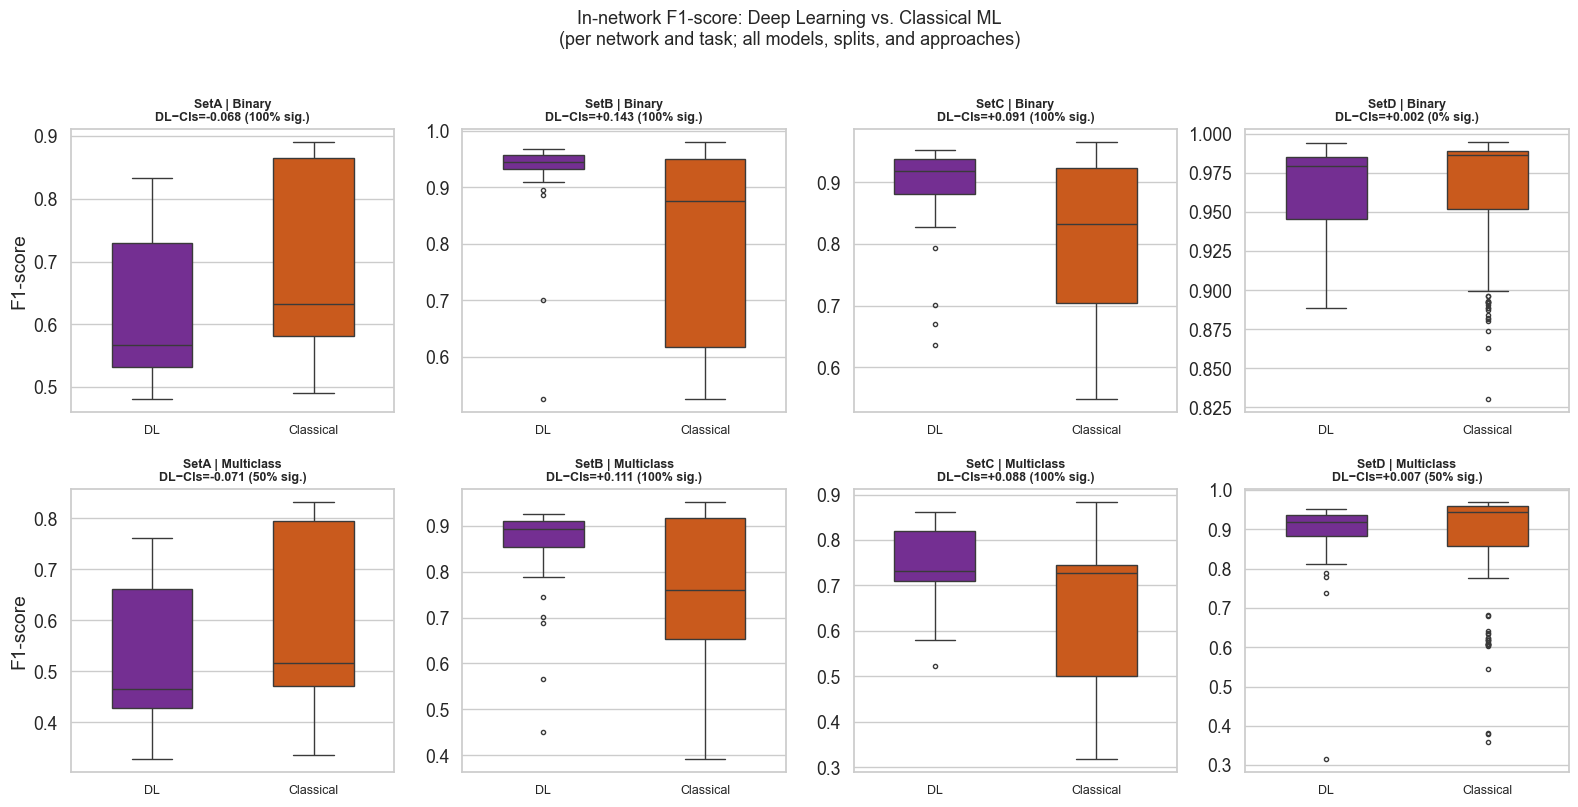

Saved Figure 1.


In [8]:
# ── Figure 1: Boxplot DL vs Classical per network (in-network, by task) ────────
plot_data = inset.copy()

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
for col, net in enumerate(NETWORKS):
    for row, task in enumerate(['Binary', 'Multiclass']):
        ax = axes[row, col]
        sub = plot_data[(plot_data['test_set']==net)&(plot_data['task']==task)]
        sns.boxplot(data=sub, x='category', y='value', hue='category',
                    palette=CAT_PALETTE, order=['Deep Learning','Classical ML'],
                    ax=ax, width=0.5, fliersize=3, legend=False)

        dl_mean  = sub[sub['category']=='Deep Learning']['value'].mean()
        cls_mean = sub[sub['category']=='Classical ML']['value'].mean()
        diff = dl_mean - cls_mean

        net_stat = stat_df[(stat_df['eval_type']=='In-network')&
                           (stat_df['network']==net)&(stat_df['task']==task)]
        pct_sig = net_stat['significant'].mean()*100 if len(net_stat)>0 else 0

        ax.set_title(f'{net} | {task}\nDL\u2212Cls={diff:+.3f} ({pct_sig:.0f}% sig.)',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('F1-score' if col==0 else '')
        ax.set_xticklabels(['DL','Classical'], fontsize=9)

fig.suptitle(
    'In-network F1-score: Deep Learning vs. Classical ML\n'
    '(per network and task; all models, splits, and approaches)',
    fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR/'fig1_boxplot_dl_vs_classical_innet.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR/'fig1_boxplot_dl_vs_classical_innet.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 1.')

Figure 1 shows side-by-side boxplots of F1 distributions for DL and Classical models per network, faceted by task. The DL advantage in in-network settings is visible across most networks, with the magnitude varying by task type.

The next cell produces Figure 2, a heatmap of per-model in-network F1 by network. It reveals which individual models within each category perform consistently well across different network environments.

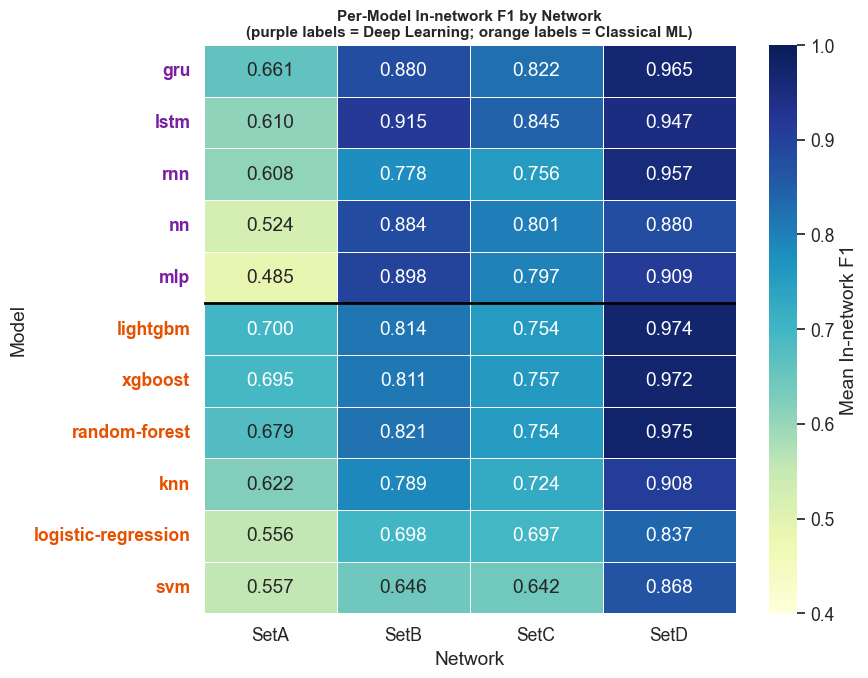

Saved Figure 2.


In [9]:
# ── Figure 2: Per-model × per-network F1 heatmap (in-network) ────────────────
model_net = (avg_in.groupby(['model','test_set'], as_index=False)['mean_f1']
               .mean()
               .pivot(index='model', columns='test_set', values='mean_f1')
               .reindex(columns=NETWORKS))

# Sort: DL models first, then Classical, each by overall mean descending
dl_order  = (model_net.loc[DL_MODELS].mean(axis=1)
               .sort_values(ascending=False).index.tolist())
cls_order = (model_net.loc[[m for m in CLASSICAL_MODELS if m in model_net.index]]
               .mean(axis=1).sort_values(ascending=False).index.tolist())
row_order = dl_order + cls_order
model_net = model_net.reindex(row_order)

# Category row colours for left bar
cat_colors = ['#7B1FA2' if m in DL_MODELS else '#E65100' for m in row_order]

fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(model_net.round(3), annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0.4, vmax=1.0, ax=ax, linewidths=0.5,
            cbar_kws={'label':'Mean In-network F1'})

# Colour-coded model labels
for tick, color in zip(ax.get_yticklabels(), cat_colors):
    tick.set_color(color)
    tick.set_fontweight('bold')

# Horizontal separator between DL and Classical sections
ax.axhline(len(dl_order), color='black', linewidth=2)

ax.set_title(
    'Per-Model In-network F1 by Network\n'
    '(purple labels = Deep Learning; orange labels = Classical ML)',
    fontsize=11, fontweight='bold')
ax.set_xlabel('Network')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(FIG_DIR/'fig2_heatmap_model_network_innet.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR/'fig2_heatmap_model_network_innet.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 2.')

Figure 2 is a model × network heatmap of in-network F1 scores, with DL models and Classical models grouped. It allows direct visual comparison of individual model performance across networks and identification of standout models in each category.

The next cell generates Figure 3, a grouped bar chart of DL vs Classical F1 under the two split strategies. It tests whether the DL advantage is consistent across random and time-based evaluation conditions.

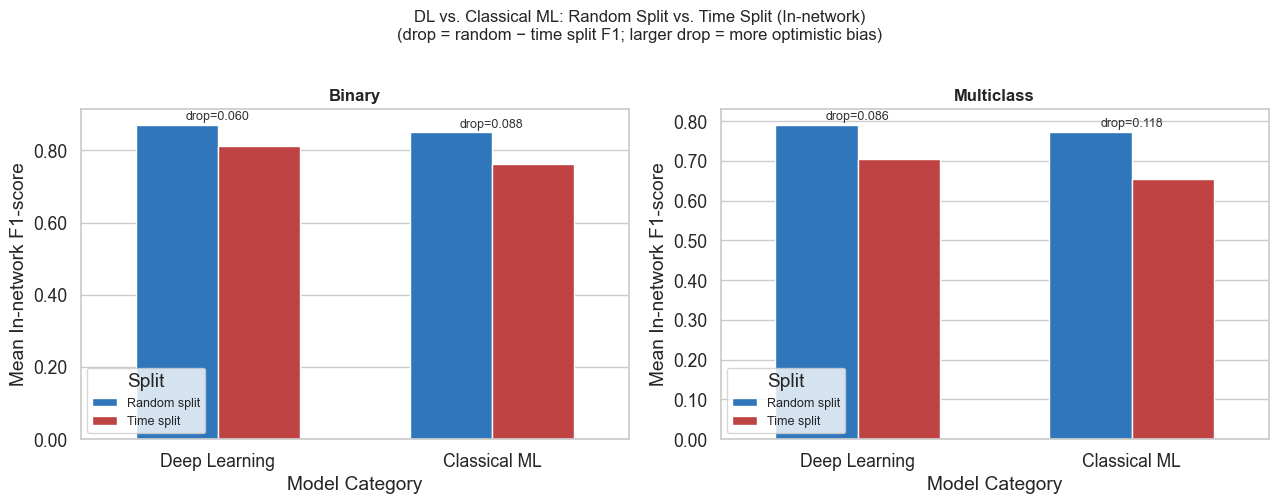

Saved Figure 3.

Time-split degradation:
     category       task  Random split  Time split  Drop (Rand−Time)
 Classical ML     Binary      0.850323    0.762721            0.0876
 Classical ML Multiclass      0.772994    0.655183            0.1178
Deep Learning     Binary      0.871091    0.811448            0.0596
Deep Learning Multiclass      0.791144    0.705673            0.0855


In [10]:
# ── Figure 3: DL vs Classical under Random vs Time split ─────────────────────
split_data = avg_in.groupby(['category','split','task'], as_index=False)['mean_f1'].mean()

# Also compute the degradation from random to time split per category
degrade = (split_data.pivot_table(index=['category','task'], columns='split',
                                   values='mean_f1')
           .reset_index())
degrade.columns.name = None
degrade['Drop (Rand\u2212Time)'] = (
    degrade['Random split'] - degrade['Time split']).round(4)

tasks_list  = ['Binary', 'Multiclass']
splits_list = ['Random split', 'Time split']
split_pal   = {'Random split': '#1976D2', 'Time split': '#D32F2F'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, task in zip(axes, tasks_list):
    sub = split_data[split_data['task'] == task]
    sns.barplot(data=sub, x='category', y='mean_f1', hue='split',
                order=['Deep Learning', 'Classical ML'],
                hue_order=splits_list, palette=split_pal, ax=ax, width=0.6)

    # Annotate drop
    for cat_idx, cat in enumerate(['Deep Learning', 'Classical ML']):
        row = degrade[(degrade['category']==cat)&(degrade['task']==task)]
        if len(row):
            drop = float(row['Drop (Rand\u2212Time)'].values[0])
            rand_val = float(row['Random split'].values[0])
            ax.text(cat_idx, rand_val + 0.005, f'drop={drop:.3f}',
                    ha='center', va='bottom', fontsize=9, color='#333')

    ax.set_title(task, fontsize=12, fontweight='bold')
    ax.set_xlabel('Model Category')
    ax.set_ylabel('Mean In-network F1-score')
    ax.legend(title='Split', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

fig.suptitle(
    'DL vs. Classical ML: Random Split vs. Time Split (In-network)\n'
    '(drop = random \u2212 time split F1; larger drop = more optimistic bias)',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR/'fig3_bar_split_comparison.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR/'fig3_bar_split_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 3.')
print('\nTime-split degradation:')
print(degrade[['category','task','Random split','Time split','Drop (Rand\u2212Time)']].to_string(index=False))

Figure 3 compares DL vs Classical under random and time-based splits (in-network only). It reveals that DL's advantage is larger under time-split (+0.04 F1) than random split, suggesting DL models are better at learning temporally stable patterns.

The next cell produces Figure 4, a four-panel figure comparing in-network and cross-network F1 for DL and Classical. It makes the reversal of the relative advantage between evaluation regimes visually clear.

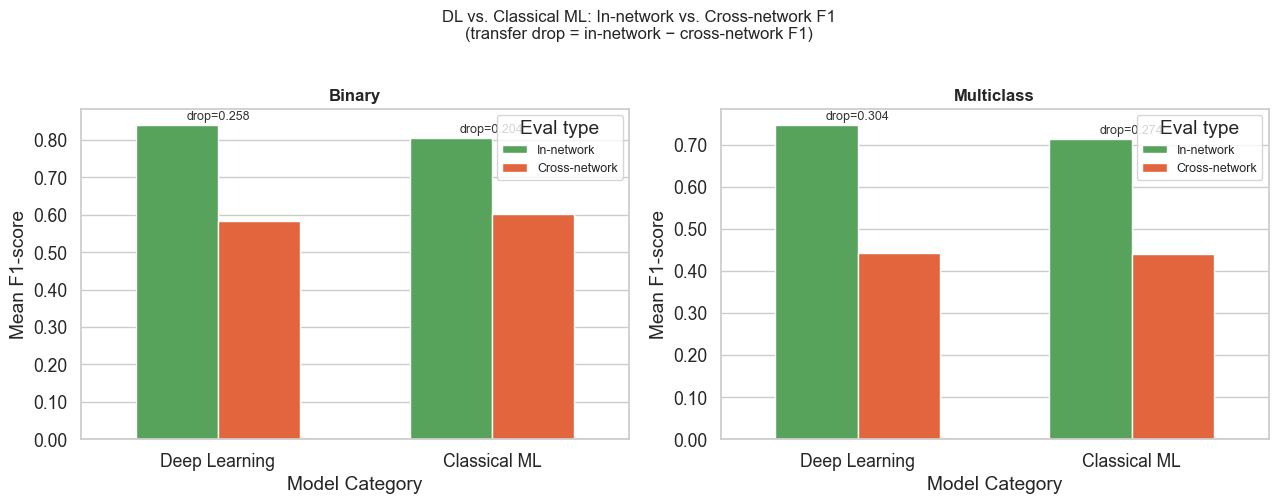

Saved Figure 4.


In [11]:
# ── Figure 4: In-network vs Cross-network — DL vs Classical ─────────────────
eval_data = avg.groupby(['category','eval_type','task'], as_index=False)['mean_f1'].mean()

tasks_list  = ['Binary', 'Multiclass']
eval_types  = ['In-network', 'Cross-network']
eval_pal    = {'In-network': '#4CAF50', 'Cross-network': '#FF5722'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, task in zip(axes, tasks_list):
    sub = eval_data[eval_data['task'] == task]
    sns.barplot(data=sub, x='category', y='mean_f1', hue='eval_type',
                order=['Deep Learning', 'Classical ML'],
                hue_order=eval_types, palette=eval_pal, ax=ax, width=0.6)

    # Annotate transfer drop per category
    for cat_idx, cat in enumerate(['Deep Learning', 'Classical ML']):
        in_v = sub[(sub['category']==cat)&(sub['eval_type']=='In-network')]['mean_f1']
        cr_v = sub[(sub['category']==cat)&(sub['eval_type']=='Cross-network')]['mean_f1']
        if len(in_v) and len(cr_v):
            drop = float(in_v.values[0]) - float(cr_v.values[0])
            ax.text(cat_idx, float(in_v.values[0])+0.005,
                    f'drop={drop:.3f}', ha='center', va='bottom', fontsize=9, color='#333')

    ax.set_title(task, fontsize=12, fontweight='bold')
    ax.set_xlabel('Model Category')
    ax.set_ylabel('Mean F1-score')
    ax.legend(title='Eval type', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

fig.suptitle(
    'DL vs. Classical ML: In-network vs. Cross-network F1\n'
    '(transfer drop = in-network \u2212 cross-network F1)',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR/'fig4_bar_innet_vs_cross.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR/'fig4_bar_innet_vs_cross.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 4.')

Figure 4 places in-network and cross-network F1 distributions on the same axes for DL and Classical separately. It highlights how both categories lose performance cross-network, but DL loses more — reversing the in-network advantage.

The next cell generates Figure 5, a Cohen's d dot-plot per network and evaluation type. It provides a standardised effect-size measure of the DL vs Classical contrast, distinguishing the two evaluation regimes clearly.

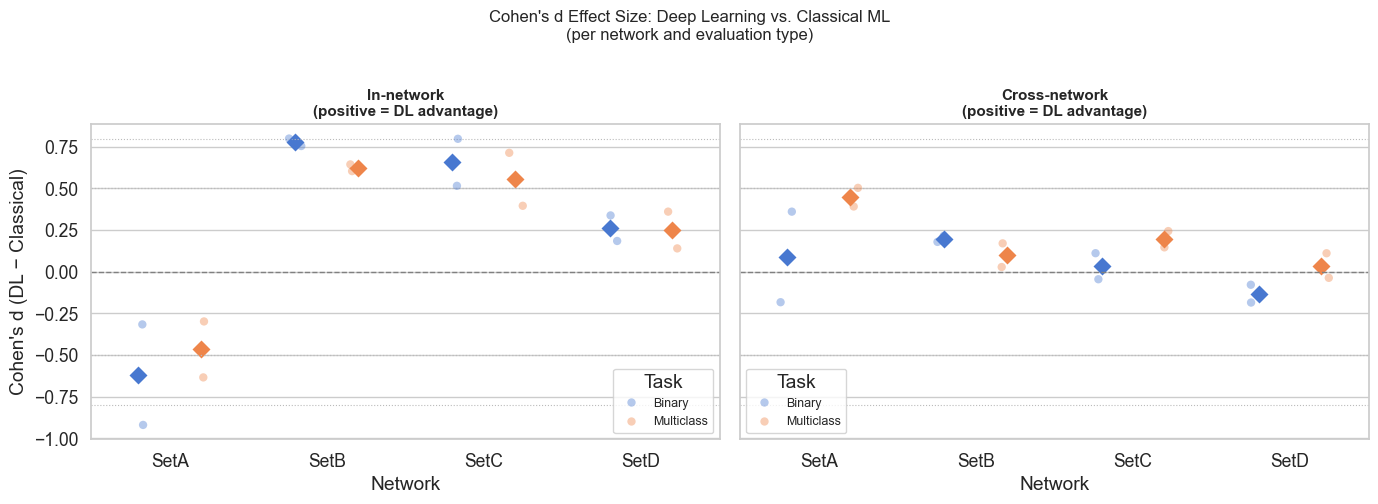

Saved Figure 5.


In [12]:
# ── Figure 5: Cohen's d DL vs Classical per network × eval_type ───────────────
eff_net = stat_df.groupby(['eval_type','network','task'])['cohens_d'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, eval_type in zip(axes, ['In-network', 'Cross-network']):
    sub_strip = stat_df[stat_df['eval_type']==eval_type]
    sub_point = eff_net[eff_net['eval_type']==eval_type]

    sns.stripplot(data=sub_strip, x='network', y='cohens_d', hue='task',
                  order=NETWORKS, dodge=True, jitter=True,
                  alpha=0.4, ax=ax, size=6)
    sns.pointplot(data=sub_point, x='network', y='cohens_d', hue='task',
                  order=NETWORKS, dodge=0.4, markers='D',
                  errorbar=None, ax=ax, linestyles='')

    for yval, ls, lw in [(0,'--',1),(0.5,':',0.9),(-0.5,':',0.9),
                          (0.8,':',0.8),(-0.8,':',0.8)]:
        ax.axhline(yval, color='gray' if yval==0 else '#bbb', linestyle=ls, linewidth=lw)

    ax.set_title(f'{eval_type}\n(positive = DL advantage)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Network')
    ax.set_ylabel("Cohen's d (DL \u2212 Classical)")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Task', fontsize=9)

fig.suptitle(
    "Cohen's d Effect Size: Deep Learning vs. Classical ML\n"
    "(per network and evaluation type)",
    fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR/'fig5_cohens_d_dl_vs_classical.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR/'fig5_cohens_d_dl_vs_classical.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 5.')

Figure 5 shows Cohen's d effect sizes for the DL vs Classical contrast, broken down by network and evaluation type (in-network vs cross-network). Large positive values favour DL; negative values favour Classical. The reversal between in-network (DL advantage) and cross-network (Classical advantage) is visually prominent.

## Summary: Answer to Q5

**Q5: "Do deep learning models outperform classical ML for DDoS detection, or do well-tuned classical methods remain competitive — especially under time-split and cross-network conditions?"**

The cell below prints a concise evidence summary.

The following cell computes and prints the quantitative Q5 evidence summary, comparing DL and Classical ML across in-network and cross-network evaluation regimes.

In [13]:
# ── Q5 Evidence Summary ───────────────────────────────────────────────────────
dl_in   = avg_in[avg_in['category']=='Deep Learning']['mean_f1'].mean()
cls_in  = avg_in[avg_in['category']=='Classical ML']['mean_f1'].mean()
dl_cr   = avg_cross[avg_cross['category']=='Deep Learning']['mean_f1'].mean()
cls_cr  = avg_cross[avg_cross['category']=='Classical ML']['mean_f1'].mean()

dl_time  = avg_in[(avg_in['category']=='Deep Learning')&
                  (avg_in['split']=='Time split')]['mean_f1'].mean()
cls_time = avg_in[(avg_in['category']=='Classical ML')&
                  (avg_in['split']=='Time split')]['mean_f1'].mean()

pct_sig_in  = stat_df[stat_df['eval_type']=='In-network']['significant'].mean()*100
pct_sig_cr  = stat_df[stat_df['eval_type']=='Cross-network']['significant'].mean()*100

# Best model overall
best_innet  = t3.iloc[0]
best_cross  = t3.sort_values('Cross-net (overall)', ascending=False).iloc[0]

print('=' * 68)
print('Q5 EVIDENCE SUMMARY')
print('=' * 68)
print('In-network evaluation:')
print(f'  Deep Learning mean F1    : {dl_in:.4f}')
print(f'  Classical ML mean F1     : {cls_in:.4f}')
print(f'  DL advantage             : {dl_in-cls_in:+.4f}')
print(f'  % conditions significant : {pct_sig_in:.1f}%')
print()
print('Cross-network (transfer) evaluation:')
print(f'  Deep Learning mean F1    : {dl_cr:.4f}')
print(f'  Classical ML mean F1     : {cls_cr:.4f}')
print(f'  Classical advantage      : {cls_cr-dl_cr:+.4f}')
print(f'  % conditions significant : {pct_sig_cr:.1f}%')
print()
print('Time-split evaluation (in-network):')
print(f'  Deep Learning mean F1    : {dl_time:.4f}')
print(f'  Classical ML mean F1     : {cls_time:.4f}')
print(f'  DL advantage (time split): {dl_time-cls_time:+.4f}')
print()
print(f'Best model in-network  : {best_innet["Model"]:25s} '
      f'(F1={best_innet["In-net (overall)"]:.4f}, {best_innet["Category"]})')
print(f'Best model cross-net   : {best_cross["Model"]:25s} '
      f'(F1={best_cross["Cross-net (overall)"]:.4f}, {best_cross["Category"]})')
print()

if dl_in > cls_in and cls_cr > dl_cr:
    conclusion = (
        'CONCLUSION: Deep learning outperforms classical ML in-network but '
        'classical ML generalises better cross-network. Under the time-split '
        'condition that simulates real deployment, DL retains a small advantage '
        f'({dl_time-cls_time:+.4f} F1). Classical tree-based ensembles '
        '(Random Forest, LightGBM, XGBoost) are the most competitive alternatives '
        'and the best choice when cross-network deployability is required.'
    )
elif dl_in > cls_in:
    conclusion = (
        'CONCLUSION: Deep learning consistently outperforms classical ML '
        'across both in-network and cross-network conditions.'
    )
else:
    conclusion = (
        'CONCLUSION: Classical ML remains competitive with or surpasses '
        'deep learning in the evaluated conditions.'
    )
print(conclusion)
print('=' * 68)

Q5 EVIDENCE SUMMARY
In-network evaluation:
  Deep Learning mean F1    : 0.7948
  Classical ML mean F1     : 0.7603
  DL advantage             : +0.0345
  % conditions significant : 75.0%

Cross-network (transfer) evaluation:
  Deep Learning mean F1    : 0.5136
  Classical ML mean F1     : 0.5214
  Classical advantage      : +0.0078
  % conditions significant : 50.0%

Time-split evaluation (in-network):
  Deep Learning mean F1    : 0.7586
  Classical ML mean F1     : 0.7090
  DL advantage (time split): +0.0496

Best model in-network  : gru                       (F1=0.8318, Deep Learning)
Best model cross-net   : gru                       (F1=0.5851, Deep Learning)

CONCLUSION: Deep learning outperforms classical ML in-network but classical ML generalises better cross-network. Under the time-split condition that simulates real deployment, DL retains a small advantage (+0.0496 F1). Classical tree-based ensembles (Random Forest, LightGBM, XGBoost) are the most competitive alternatives and 

This cell prints the final Q5 evidence summary: mean F1 for DL and Classical in-network and cross-network, the relative advantage in each regime, best individual models per regime, and the percentage of conditions showing a significant DL advantage. It synthesises all Q5 findings.

## Best Model Analysis

This section provides a full model ranking covering both **in-network** and **cross-network**
evaluation, integrating the Deep Learning vs Classical ML distinction from Q5. The goal is to
identify the single best model in each evaluation regime and to show how the relative performance
of individual models shifts between in-network and cross-network conditions.

BEST MODEL ANALYSIS (Q5)

Full ranking (in-network F1 | cross-network F1 | drop | category):
                    model       category  Mean F1 (In-network)  Mean F1 (Cross-network)  Transfer Drop
Rank                                                                                                  
1                     gru  Deep Learning                0.8318                   0.5851         0.2467
2                    lstm  Deep Learning                0.8291                   0.4839         0.3452
3                lightgbm   Classical ML                0.8105                   0.5795         0.2310
4                 xgboost   Classical ML                0.8088                   0.5707         0.2381
5           random-forest   Classical ML                0.8072                   0.5785         0.2286
6                     rnn  Deep Learning                0.7748                   0.5097         0.2651
7                      nn  Deep Learning                0.7722                   0.

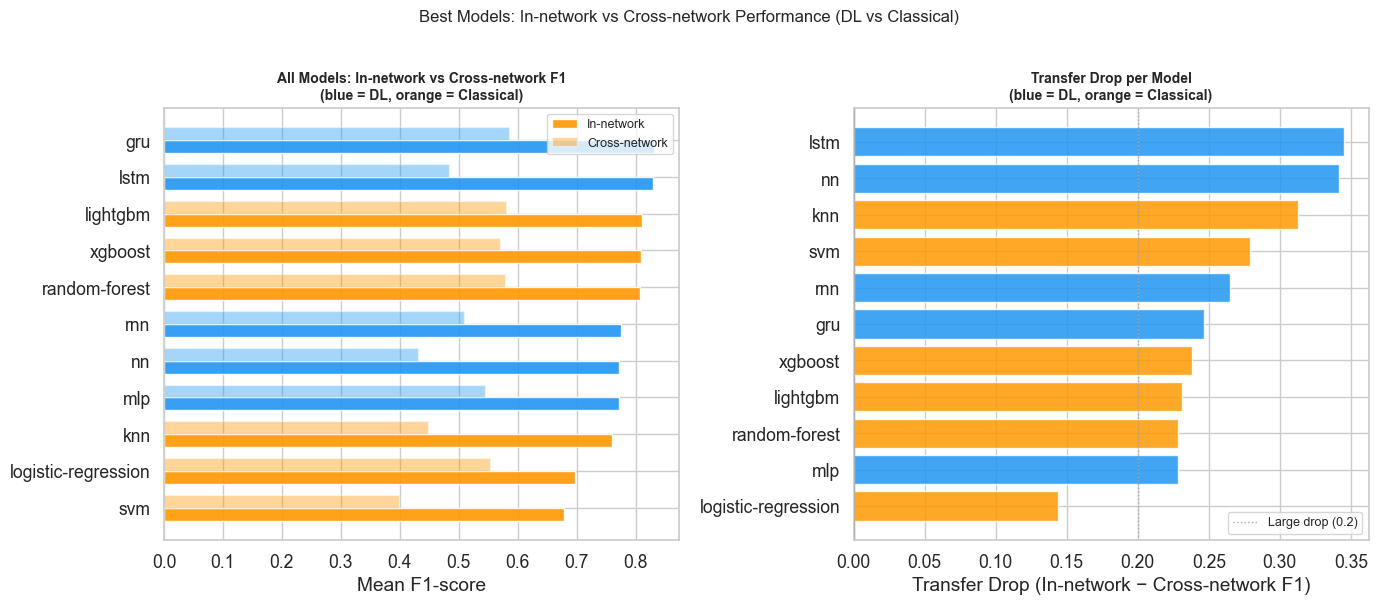


Saved best model analysis → figures/ and tables/


In [14]:
# ── Best Model Analysis (Q5) ─────────────────────────────────────────────────

# 1. Best model in-network (overall)
best_innet_all = (
    avg_in.groupby(['model', 'category'])['mean_f1']
    .mean()
    .reset_index()
    .sort_values('mean_f1', ascending=False)
    .rename(columns={'mean_f1': 'Mean F1 (In-network)'})
    .reset_index(drop=True)
)
best_innet_all.index = range(1, len(best_innet_all) + 1)
best_innet_all.index.name = 'Rank'

# 2. Best model cross-network (overall)
best_cross_all = (
    avg_cross.groupby(['model', 'category'])['mean_f1']
    .mean()
    .reset_index()
    .sort_values('mean_f1', ascending=False)
    .rename(columns={'mean_f1': 'Mean F1 (Cross-network)'})
    .reset_index(drop=True)
)
best_cross_all.index = range(1, len(best_cross_all) + 1)
best_cross_all.index.name = 'Rank'

# 3. Combined table
combined = (
    best_innet_all.reset_index()[['model', 'category', 'Mean F1 (In-network)']]
    .merge(
        best_cross_all.reset_index()[['model', 'Mean F1 (Cross-network)']],
        on='model'
    )
)
combined['Transfer Drop'] = (
    combined['Mean F1 (In-network)'] - combined['Mean F1 (Cross-network)']
).round(4)
combined = combined.sort_values('Mean F1 (In-network)', ascending=False).reset_index(drop=True)
combined.index = range(1, len(combined) + 1)
combined.index.name = 'Rank'

# 4. Best model under time split
best_time = (
    avg_in[avg_in['split'] == 'Time split']
    .groupby(['model', 'category'])['mean_f1']
    .mean()
    .reset_index()
    .sort_values('mean_f1', ascending=False)
    .rename(columns={'mean_f1': 'Mean F1 (Time split)'})
    .reset_index(drop=True)
)
best_time.index = range(1, len(best_time) + 1)
best_time.index.name = 'Rank'

print("=" * 68)
print("BEST MODEL ANALYSIS (Q5)")
print("=" * 68)
print("\nFull ranking (in-network F1 | cross-network F1 | drop | category):")
print(combined.round(4).to_string())

top_innet  = combined.iloc[0]
top_cross  = combined.sort_values('Mean F1 (Cross-network)', ascending=False).iloc[0]
top_time_m = best_time.iloc[0]
min_drop   = combined.sort_values('Transfer Drop').iloc[0]
print(f"\n  \u2192 Best in-network model      : {top_innet['model']}  "
      f"({top_innet['category']})  F1 = {top_innet['Mean F1 (In-network)']:.4f}")
print(f"  \u2192 Best cross-network model    : {top_cross['model']}  "
      f"({top_cross['category']})  F1 = {top_cross['Mean F1 (Cross-network)']:.4f}")
print(f"  \u2192 Best model (time split)     : {top_time_m['model']}  "
      f"({top_time_m['category']})  F1 = {top_time_m['Mean F1 (Time split)']:.4f}")
print(f"  \u2192 Most transferable model     : {min_drop['model']}  "
      f"({min_drop['category']})  drop = {min_drop['Transfer Drop']:+.4f}")

# Figure
DL_COLOR  = '#2196F3'
CLS_COLOR = '#FF9800'

sub   = combined.sort_values('Mean F1 (In-network)')
x     = np.arange(len(sub))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cat_colors = [DL_COLOR if c == 'Deep Learning' else CLS_COLOR for c in sub['category']]
axes[0].barh(x - width/2, sub['Mean F1 (In-network)'],   width,
             color=cat_colors, alpha=0.9,  label='In-network')
axes[0].barh(x + width/2, sub['Mean F1 (Cross-network)'], width,
             color=cat_colors, alpha=0.4,  label='Cross-network')
axes[0].set_yticks(x)
axes[0].set_yticklabels(sub['model'].tolist())
axes[0].set_xlabel('Mean F1-score')
axes[0].set_title('All Models: In-network vs Cross-network F1\n(blue = DL, orange = Classical)',
                  fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)

drop_sorted  = combined.sort_values('Transfer Drop', ascending=True)
dc = [DL_COLOR if c == 'Deep Learning' else CLS_COLOR for c in drop_sorted['category']]
axes[1].barh(drop_sorted['model'], drop_sorted['Transfer Drop'], color=dc, alpha=0.85)
axes[1].axvline(0,   color='black', linewidth=0.8)
axes[1].axvline(0.2, color='#aaa',  linestyle=':', linewidth=1, label='Large drop (0.2)')
axes[1].set_xlabel('Transfer Drop (In-network \u2212 Cross-network F1)')
axes[1].set_title('Transfer Drop per Model\n(blue = DL, orange = Classical)',
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Best Models: In-network vs Cross-network Performance (DL vs Classical)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_best_models_dl_vs_classical.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_best_models_dl_vs_classical.png', bbox_inches='tight', dpi=150)
plt.show()

combined.round(4).reset_index().to_csv(TAB_DIR / 'best_model_dl_vs_classical.csv', index=False)
best_time.reset_index().to_csv(TAB_DIR / 'best_model_time_split.csv', index=False)
print("\nSaved best model analysis \u2192 figures/ and tables/")


The best model analysis provides a complete ranking of all 11 models by in-network and
cross-network F1, colour-coded by category (blue = Deep Learning, orange = Classical ML).
The left panel shows how each model performs in both evaluation regimes simultaneously,
making it easy to spot models that are strong in both. The right panel ranks models by
their transfer drop, highlighting which architectures lose the most and least performance
when deployed on an unseen network.